In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import os
from labellines import labelLine

import warnings
warnings.filterwarnings("ignore")

Generate 100 models ranging from 0% aligned to 100% aligned. 

For each of these compute a KS-test and determine at which fraction of misaligned outflows does the probability go below 0.1 and 0.01.

In [101]:
# READ DATA
outflow_data = pd.read_csv('../data/output/outflow_data.csv')
data = outflow_data.loc[~outflow_data['delta_PA'].isna()]

In [102]:
def createCumulatPlotDeg(datax, datay, datalabel='', title='', xlabel='', filename='test'):
    fig, ax = plt.subplots(figsize=(11,8))
    
    # get labels
    if datalabel == '':
        datalabel = [''] * len(datax)
    
    # Loop through each dataset and plot it as a step function
    colors = ['#4477AA', '#AA3377', '#66CCEE', '#CCBB44', '#228833', '#EE6677']
    for i in range(len(datax)):
        ax.step(datax[i], datay[i], label=datalabel[i], color=colors[i%5], linewidth=2.0)
        
    # PLOT
    ax.set_title(title, fontsize=28, pad=10)
    ax.set_xlabel(xlabel, fontsize=20, labelpad=15)
    ax.set_ylabel('frequency', fontsize=20, labelpad=15)
    # ax.legend(fontsize=13)

    # labelLine(ax.get_lines()[0], x=16, align=False, rotation=0, yoffset=-0.018, fontsize=14)
    # labelLine(ax.get_lines()[1], x=35, align=False, rotation=24, yoffset=0.03, fontsize=14)
    # labelLine(ax.get_lines()[2], x=55, align=False, rotation=28, yoffset=0.03, fontsize=14)
    # labelLine(ax.get_lines()[3], x=40, align=False, rotation=30, yoffset=0.035, fontsize=14)
    # labelLine(ax.get_lines()[4], x=45, align=False, rotation=32, yoffset=0.03, fontsize=14)
    # labelLine(ax.get_lines()[5], x=50, align=False, rotation=30, yoffset=0.03, fontsize=14)

    ax.set_xlim(0, 90.0)
    ax.set_ylim(0, 1.0)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

    # plt.savefig(filename + '.pdf', dpi=200)
    # plt.savefig(filename + '.png', dpi=300, transparent=True, bbox_inches='tight')

def makeCumulate(arrayData):
    # sort ascending
    sorted_pas = np.sort(arrayData, axis=None)
    # get length
    number = len(sorted_pas)
    # Compute cumulative fraction (normalized by total number of elements)
    frac_cum = (np.arange(0, number, dtype=np.float32)) / float(number)

    return sorted_pas, frac_cum

In [103]:
# Generate cumulative distributions for observed data
paCumulat_deg, frac_paCumulat_deg = makeCumulate(data['delta_PA'][:])

# Generate random position angles and project them
num_samples = 100000
pa = np.random.uniform(0, 90, num_samples) # binary PA
ofa = np.random.uniform(0, 90, num_samples) # random outflow PA offset
inc = np.random.random_sample(num_samples) # inclination
R = np.random.uniform(30.0, 300.0, num_samples) # binary separation distance
projx = R * np.cos(np.radians(pa)) # project binary PA to 2D plane
projy = R * np.sin(np.radians(pa)) * inc # project binary PA to 2D plane
projpa = 90.0 - np.degrees(np.arctan2(projy, projx)) # expected orthogonal outflow PA
projpa_rand = np.abs(ofa - np.degrees(np.arctan2(projy, projx))) # random outflow PA

cumulates = []
ks_pvalues = []
for i in range(0, 101, 1):
    # for i = 1, add 99% from projpa and 1% from projpa_rand
    index = 1000*(100-i)
    # create different percentage-randomized datasets
    d = np.concatenate((projpa[:index], projpa_rand[index:]))
    # create cumulative distribution
    c = makeCumulate(d)
    cumulates.append(c)
    # perform KS test
    ks_pvalues.append({"% random": i, "p": stats.ks_2samp(paCumulat_deg, c[0]).pvalue})

# Generate cumulative plots
# createCumulatPlotDeg(np.array(cumulates)[:,0], np.array(cumulates)[:,1], datalabel=[f"{p}% Orthogonal" for p in range(0, 101, 1)], title='$\\Delta$PA Cumulative Frequency Distribution', xlabel='$\\Delta$PA - smallest angle between binary separation and outflow (degrees)', filename=os.path.join("", 'OutflowPA_cumulat_deg'))

In [104]:
ks_pvalues = pd.DataFrame(ks_pvalues)
ks_pvalues

,% random,p
0,0,5.066019e-01
1,1,5.342018e-01
2,2,5.617049e-01
3,3,5.919079e-01
4,4,6.208129e-01
...,...,...
96,96,1.062998e-09
97,97,7.292511e-10
98,98,4.959300e-10
99,99,3.320241e-10


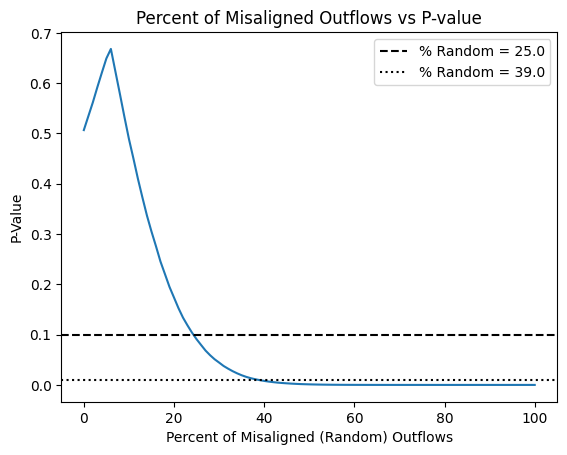

In [105]:
plt.plot(ks_pvalues['% random'], ks_pvalues['p'])
plt.xlabel('Percent of Misaligned (Random) Outflows')
plt.ylabel('P-Value')
plt.title("Percent of Misaligned Outflows vs P-value")

less_than_01 = ks_pvalues.loc[ks_pvalues['p']<0.1].iloc[0]['% random']
less_than_001 = ks_pvalues.loc[ks_pvalues['p']<0.01].iloc[0]['% random']
plt.axhline(0.1, color='k', ls='dashed', label=f'% Random = {less_than_01}')
# plt.axvline(less_than_01, color='k', ls='dashed')
plt.axhline(0.01, color='k', ls='dotted', label=f'% Random = {less_than_001}')
# plt.axvline(less_than_001, color='k', ls='dotted')

plt.legend()


Low p-value means that the distributions are not the same; High p-value means that they are likely the same.

At a simulated distribution with 25% misaligned outflows (aka 75% orthogonal), the p-value drops below 0.10.

At a simulated distribution with 39% misaligned outflows (aka 61% orthogonal), the p-value drops below 0.01. 

We are 90% confident that the distribution of outflows is >75% orthogonal, and 99% confident that the distribution of outflows is >61% orthogonal.